

This notebook is to provide some guide
on the usage of existing libraries
to finish assignment 3.
It is **NOT** necessary to follow this guide,
instead, we only aim to provide one possible solution.


## 1. Data Preprocessing

For query the relevant text data, you can check the [NLTK book](http://www.nltk.org/book_1ed/ch03.html) section 3.4-3.5.

For preprocessing,
you can use [NLTK](http://www.nltk.org/book_1ed/ch03.html) (section 3.6) or [Spacy](https://spacy.io/).
Spacy is one of the best production-ready NLP tools.


In [2]:
# For installation
# recommend local runtime, because Google colab is not really compatiable with spacy...

!pip install --upgrade spacy
!pip install tweet-preprocessor
!python -m spacy download nl_core_news_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 9.0 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.4/634.4 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.4/779.4 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 19.1 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.11.0
    Uninstalling typing_extensions-4.11.0:
      Successfully uninstalled typing_extensions-4.11.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 28.9 MB/s eta 0:00:00a 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('nl_core_news_sm')


In [ ]:
# in case you want to use google colab and google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Both spacy and NLTK support Dutch text data.
In spacy, several [Dutch models](https://spacy.io/models/nl) provide similar functions but are of different sizes.
With larger model you'll get higher accuracy,
but the time and space complexities also increase.
You can decide which model to use.

In [1]:
import spacy
from spacy.lang.nl.examples import sentences

nlp = spacy.load("nl_core_news_sm")

doc = nlp(sentences[0])
print(doc.text)
for token in doc:
    print(token.text)
#     print(token.is_stop, , token.is_punct, token.is_digit)
    print(f'stop word: {token.is_stop}, space: {token.is_space},',
          f'punctuation: {token.is_punct}, digit: {token.is_digit}')

Apple overweegt om voor 1 miljard een U.K. startup te kopen
Apple
stop word: False, space: False, punctuation: False, digit: False
overweegt
stop word: False, space: False, punctuation: False, digit: False
om
stop word: True, space: False, punctuation: False, digit: False
voor
stop word: True, space: False, punctuation: False, digit: False
1
stop word: False, space: False, punctuation: False, digit: True
miljard
stop word: False, space: False, punctuation: False, digit: False
een
stop word: True, space: False, punctuation: False, digit: False
U.K.
stop word: False, space: False, punctuation: False, digit: False
startup
stop word: False, space: False, punctuation: False, digit: False
te
stop word: True, space: False, punctuation: False, digit: False
kopen
stop word: False, space: False, punctuation: False, digit: False


In [2]:
import preprocessor as p

# filter tweets with keywords
kws = ['prik', 'spuit', 'booster', 'vaccin', 'vaccinatie', 'inenten', 'inenting']
tweets = []
data_file = 'data/raw_data.txt'
with open(data_file) as fin:
    for line in fin:
        line = line.replace('\\n', ' ')
        line = ' '.join(line.lower().strip().split())
        for kw in kws:
            if kw in line:
                tweets.append(line)
                break

print(len(tweets))
for tweet in tweets[:10]:
    print(tweet)

29390
@martwit57 @lodewijka vaccinatie wil niet zeggen dat je geen corona kan krijgen
rt @hansjmelissen: dat #vuurwerkverbod komt zeker tegelijk met het vaccin? #utrecht
nederland eindigt 2020 met woningnood, record aantallen daklozen, een ondermijnde rechtsstaat, 1 miljoen mensen in armoede en meer doden dan in enig jaar sinds wwii. en 0,0 corona vaccinaties. de verantwoordelijke premier koerst af op een verkiezingsoverwinning. mooi land.
dat jullie in 2021 allemaal een spuitje mogen krijgen. https://t.co/ohwvkgho78
@hansdeboer18 @dartagnanneke "er is ook het risico van vals-positieve resultaten. hoe meer mensen uit niet-risicogebieden worden getest, hoe hoger het percentage zou zijn.” #coronafascisme #vaccindwang #hugodejonge #spoedwet #totalcontrol https://t.co/hwwtem0cip
gaaf om zo'n #stappenplan eens uitgelegd te krijgen, zeker als je er, net als ik, helemaal geen verstand van hebt. #covid_19 #vaccination
druk op kabinet neemt toe: ’eerder vaccineren zorgpersoneel mogelijk’ https:

In [3]:
import preprocessor as p

# Clean tweets by removing URLs, emojis, reserved words, smileies, numbers
p.set_options(p.OPT.URL, p.OPT.EMOJI, p.OPT.RESERVED, p.OPT.MENTION, p.OPT.SMILEY, p.OPT.NUMBER)

tweets = [p.clean(tweet) for tweet in tweets]
for tweet in tweets[:10]:
    print(tweet)

vaccinatie wil niet zeggen dat je geen corona kan krijgen
rt : dat #vuurwerkverbod komt zeker tegelijk met het vaccin? #utrecht
nederland eindigt met woningnood, record aantallen daklozen, een ondermijnde rechtsstaat, miljoen mensen in armoede en meer doden dan in enig jaar sinds wwii. en corona vaccinaties. de verantwoordelijke premier koerst af op een verkiezingsoverwinning. mooi land.
dat jullie in allemaal een spuitje mogen krijgen.
"er is ook het risico van vals-positieve resultaten. hoe meer mensen uit niet-risicogebieden worden getest, hoe hoger het percentage zou zijn. #coronafascisme #vaccindwang #hugodejonge #spoedwet #totalcontrol
gaaf om zo'n #stappenplan eens uitgelegd te krijgen, zeker als je er, net als ik, helemaal geen verstand van hebt. #covid_19 #vaccination
druk op kabinet neemt toe: eerder vaccineren zorgpersoneel mogelijk via #snaptuhetnog ?
was een zwaar jaar, maar de veerkracht van nederlanders is enorm. met het vaccin wordt een jaar van hoop en van licht aan he

In [4]:
import tqdm

processed_tweets = []
for tweet in tqdm.tqdm(tweets[:2000]):
    tweet = nlp(tweet)
    processed_tweet = []
    for token in tweet:
        if token.is_stop:  # remove stop words
            continue
        if token.is_punct:  # remove punctuations
            continue
        processed_tweet.append(token.lemma_)  # lemmatization
    processed_tweet = ' '.join(processed_tweet)
    processed_tweets.append(processed_tweet)

for tweet in processed_tweets[:10]:
    print(tweet)

100%|██████████| 2000/2000 [00:05<00:00, 391.80it/s]

vaccinatie zeggen corona krijgen
rt vuurwerkverbod komen tegelijk vaccin Utrecht
Nederland eindigen woningnood record aantalal daklozen ondermijn rechtsstaat miljoen mens armoede dood enig jaar wwii corona vaccinatie verantwoordelijk premier koerst verkiezingsoverwinning mooi land
allemaal spui krijgen
risico valspositiev resultaat mens niet-risicogebieden getest hoog percentage coronafascisme vaccindwang Hugodejonge Spoedwet totalcontrol
gaaf zo'n stappenplan uitleggen krijgen helemaal verstand covid_19 vaccination
druk kabinet toenemen vacciner zorgpersoneel via snaptuhetnog
zwaar jaar veerkracht Nederlanders enorm vaccin jaar hoop licht einde tunnel maken ondanks beperking mooi veilig jaarwisseling wensen allemaal goed gezond
waartoe immuunsysteem staat vaccinatie beogen Jan leggen simpel
ken huisarts vd lin vroeg inent tegenwoordig vroeg liep verkeerd vaandel vertelen liggen marketing t grondslag werking bewijzen Hugo t mee


## 2. Data Exploratory Analysis

Methods: word cloud, word length, word frequency, ...

You may think about questions such as:
 - Can you spot any differences between Twitter data and usual text data?
 - Does your exploration reveal some issues that would make it difficult to interpret the topics?
 - Can you improve the data by adding additional preprocessing steps?
 - Can you explain why we need to preprocess the data?

(-0.5, 399.5, 199.5, -0.5)

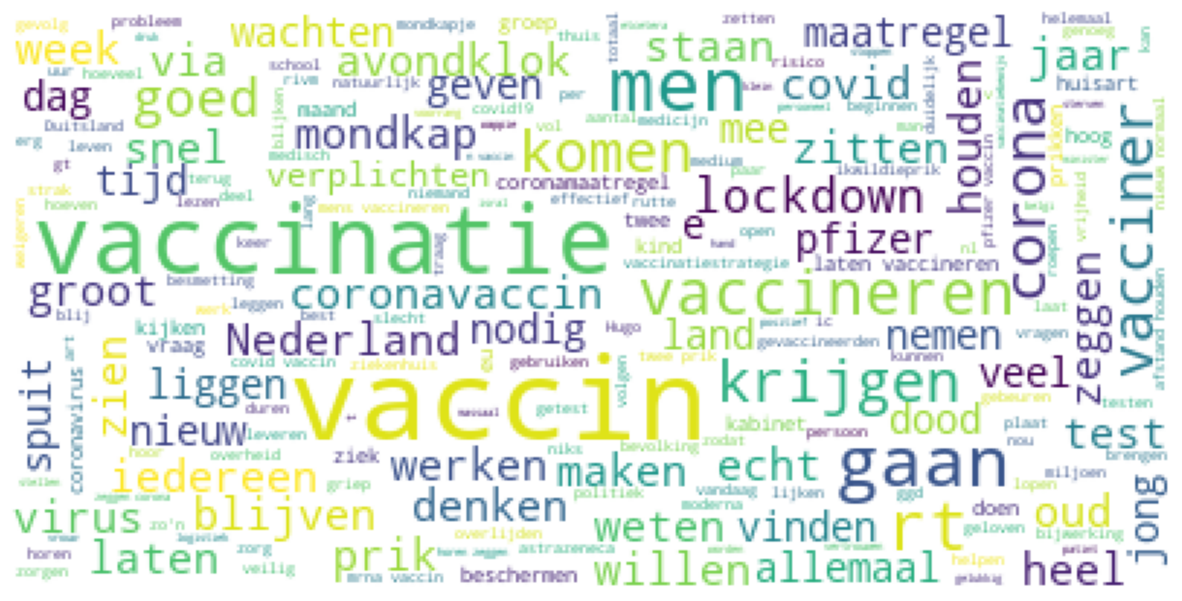

In [ ]:
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(background_color='white', max_words=500,
                      max_font_size=40, random_state=100)
wordcloud.generate(' '.join(processed_tweets))
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot()
ax.imshow(wordcloud)
ax.axis('off')

(-0.5, 399.5, 199.5, -0.5)

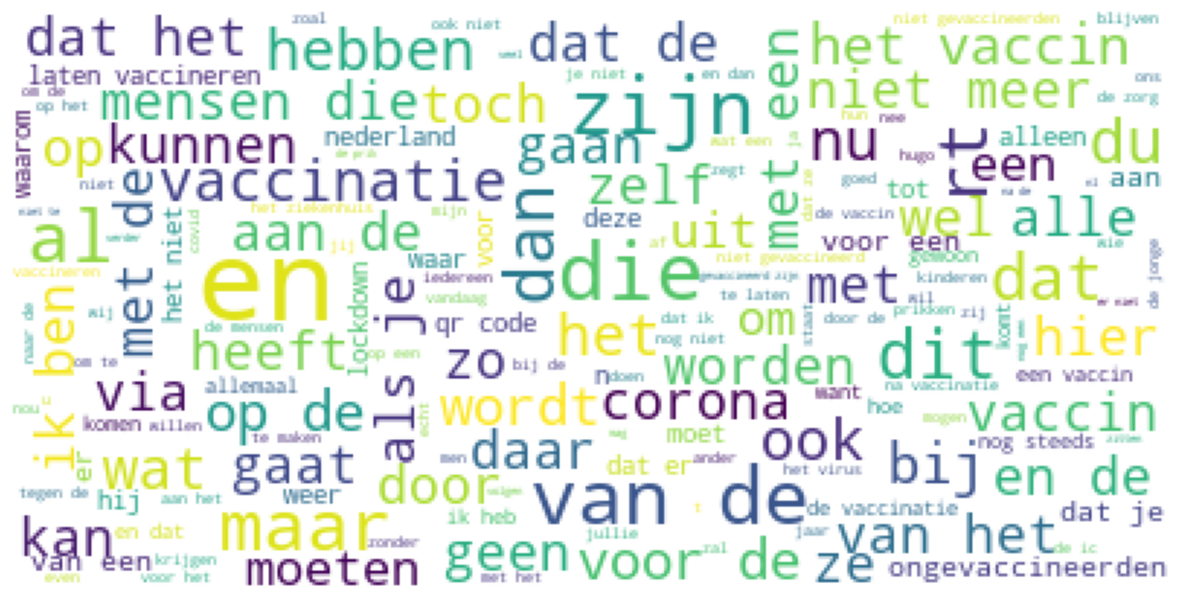

In [7]:
# lets see what happens to the wordcloud if we didn't clean the tweets first
wordcloud = WordCloud(background_color='white', max_words=500,
                      max_font_size=40, random_state=100)
wordcloud.generate(' '.join(tweets))
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot()
ax.imshow(wordcloud)
ax.axis('off')

## 3. Topic modelling and clustering

The text data representation (vectorization) shall be consistent with the selection of algorithms. For clustering and topic modeling,
you can use
[scikit-learn](https://scikit-learn.org/stable/) or [gensim](https://radimrehurek.com/gensim/auto_examples/index.html#documentation) .

Several links could be useful:
- [Text_feature_engineering from scikit-learn](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.feature_extraction.text)
- [LDA from scikit-learn](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html)
- [LDA from gensim](https://radimrehurek.com/gensim/auto_examples/tutorials/run_lda.html#sphx-glr-auto-examples-tutorials-run-lda-py)
- [K Means from scikit-learn](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)


In [10]:
# To BoW

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
bow = vectorizer.fit_transform(processed_tweets)
bow_array = bow.toarray()
print(bow_array)
print(bow_array.shape)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
(2000, 6990)


In [11]:
print(bow.__dir__())

['_shape', 'maxprint', 'indices', 'indptr', 'data', '__module__', '__doc__', 'format', 'transpose', 'tolil', 'tocsr', 'tocsc', 'tobsr', '_swap', '__iter__', 'getrow', 'getcol', '_get_intXarray', '_get_intXslice', '_get_sliceXint', '_get_sliceXarray', '_get_arrayXint', '_get_arrayXslice', '__init__', 'getnnz', '_set_self', 'check_format', '_scalar_binopt', '__eq__', '__ne__', '_inequality', '__lt__', '__gt__', '__le__', '__ge__', '_add_dense', '_add_sparse', '_sub_sparse', 'multiply', '_mul_vector', '_mul_multivector', '_mul_sparse_matrix', 'diagonal', '_maximum_minimum', 'maximum', 'minimum', 'sum', '_minor_reduce', '_get_intXint', '_get_sliceXslice', '_get_arrayXarray', '_get_columnXarray', '_major_index_fancy', '_major_slice', '_minor_index_fancy', '_minor_slice', '_get_submatrix', '_set_intXint', '_set_arrayXarray', '_set_arrayXarray_sparse', '_setdiag', '_prepare_indices', '_set_many', '_zero_many', '_insert_many', 'tocoo', 'toarray', 'eliminate_zeros', '_cs_matrix__get_has_canonic

Now You can train your LDA model based on the BoW representation above.

For text clustering methods, you should also choose the appopriate way to represent the text as input.